In [1]:
import sys
!{sys.executable} -m pip install mne

In [2]:
import mne
from mne.datasets import eegbci

# 1. Fetch BOTH datasets in one go (Eyes open and Eyes closed)
edf_files = eegbci.load_data(subjects=[1], runs=[1, 2])

# 2. Load the file, standardize, and filter
raw = mne.io.read_raw_edf(edf_files[1], preload=True)
mne.datasets.eegbci.standardize(raw)
raw.filter(1., 40., fir_design='firwin')
raw.pick_types(eeg=True)

# 3. Get data as a numpy array, then convert to a SageMath Matrix
# We use RDF (Real Double Field) for high-precision floating point math
numpy_data = raw.get_data()
data = matrix(RDF, numpy_data)

print(f"Форма матриці даних: {data.dimensions()}") 
# Outputs: (64, 15360) just like your script!

print(data[0, :10])

Extracting EDF parameters from /home/marty/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R02.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 529 samples (3.306 s)

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Форма матриці даних: (64, 9760)
[  5.082197683525802e-21  -9.980634338554797e-06  -1.483427673155278e-05  -8.345536060337052e-06   9.

In [3]:
# In Sage, .transpose() instead of .T
X = data.transpose()

means = [col.mean() for col in X.columns()]

# Create a matrix of means with the same dimensions as X to subtract it
mean_matrix = matrix(RDF, X.nrows(), X.ncols(), lambda i, j: means[j])
X_centered = X - mean_matrix

print(f"Форма матриці даних: {X_centered.dimensions()}\n")

Форма матриці даних: (9760, 64)



In [4]:
import numpy as np

# 1. Calculate Covariance
covariance_matrix = (X_centered.transpose() * X_centered) / (X.nrows() - 1)

# 2. Get eigenvalues and eigenvectors
# eigenvalues() returns a list of the eigenvalues.
# We sort them to mimic NumPy's ascending behavior.
eigenvalues = sorted(covariance_matrix.eigenvalues())

# 3. Create the threshold mask
eig_median = np.median(eigenvalues)
critical_threshold = eig_median * 10

# In Sage, list comprehensions are perfectly suited for filtering 
# instead of numpy boolean arrays:
eigenvalues_mask = [val for val in eigenvalues if val <= critical_threshold]

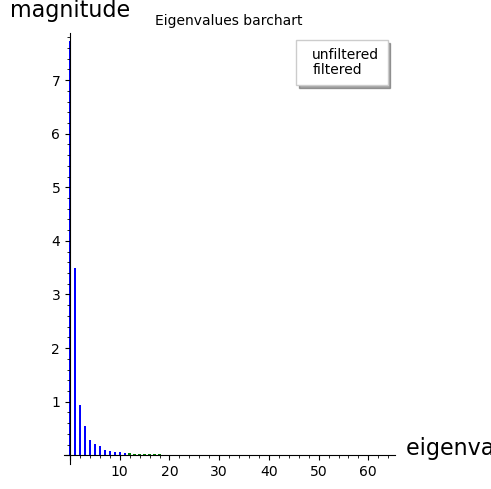

In [5]:
# We reverse the lists using [::-1]
unfiltered_bars = eigenvalues[::-1]
filtered_bars = eigenvalues_mask[::-1]

# Create the base bar chart for the unfiltered (blue)
plot1 = bar_chart(unfiltered_bars, color='blue', legend_label="unfiltered")

# need to offset them on the x-axis
offset = len(eigenvalues) - len(eigenvalues_mask)
padded_filtered = [0]*offset + filtered_bars
plot2 = bar_chart(padded_filtered, color='green', legend_label="filtered")

final_plot = plot1 + plot2

# Set the labels and title
final_plot.axes_labels(["eigenvalue id", "magnitude"])
final_plot.show(title="Eigenvalues barchart", figsize=[5, 5])

In [6]:
# 1. Get the diagonal matrix of eigenvalues (D) and eigenvectors (P)
D, P = covariance_matrix.eigenmatrix_right()

# 2. Sort them to match NumPy's ascending order (smallest to largest)
# We zip the eigenvalues with their corresponding eigenvector columns
eig_pairs = zip(D.diagonal(), P.columns())
eig_pairs_sorted = sorted(eig_pairs, key=lambda x: x[0])

# Reconstruct the sorted eigenvector matrix
eigenvectors = column_matrix(RDF, [pair[1] for pair in eig_pairs_sorted])

# 3. Project into PCA base
data_eig_base = X_centered * eigenvectors

# 4. Zero out artifacts 
bad_components_count = len(eigenvalues) - len(eigenvalues_mask)
for i in range(len(eigenvalues) - bad_components_count, len(eigenvalues)):
    for row in range(data_eig_base.nrows()):
        data_eig_base[row, i] = 0

# 5. Project back to physical channel space
X_cleaned = data_eig_base * eigenvectors.transpose()

print(f"Cleaned Data Shape: {X_cleaned.dimensions()}") 
# Outputs: (15360, 64)

Cleaned Data Shape: (9760, 64)


In [7]:
# Get metadata from the raw object
channel_names = raw.info['ch_names']
fs = raw.info['sfreq'] 

# Find the O1 channel
target = 'O1'
target_id = channel_names.index(target)

# Extract the data column from our Sage matrix
# .column() returns a vector, which we convert to a list for the FFT
target_data = list(X_cleaned.column(target_id))
N = len(target_data)

# Compute FFT using numpy (perfectly legal and standard in Sage!)
fft_values = np.fft.rfft(target_data)
fft_frequencies = np.fft.rfftfreq(N, 1/fs)
fft_power = np.abs(fft_values) ** 2

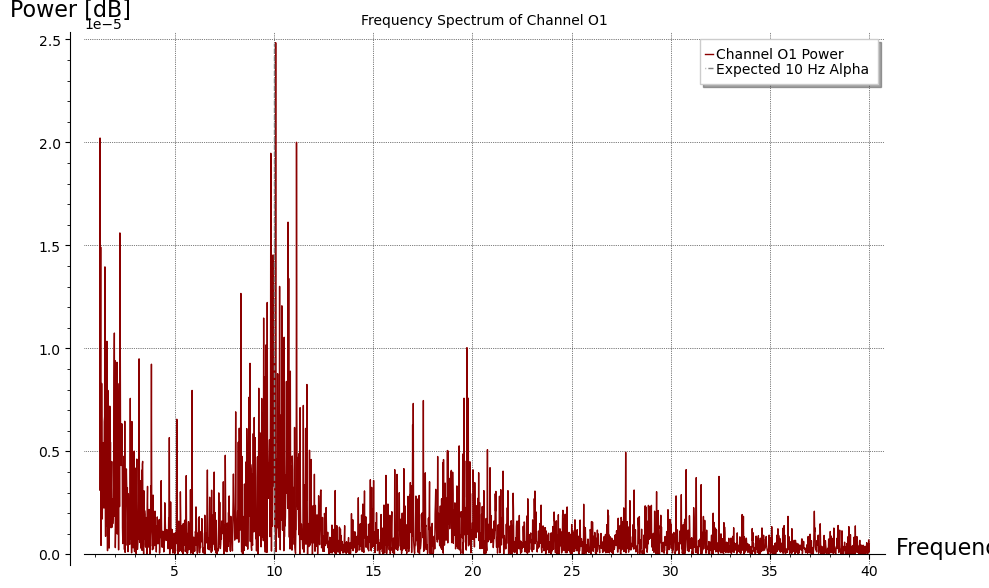

In [12]:
# 1. Zip the X (frequencies) and Y (power) arrays together to create (x, y) points
fft_points = list(zip(fft_frequencies, fft_power))

# 2. Create the main frequency spectrum line
# We truncate the points up to 40 Hz using list comprehension instead of plt.xlim
fft_points_zoomed = [(x, y) for x, y in fft_points if x <= 40 and x > 1.21]
spectrum_plot = line(fft_points_zoomed, color='darkred', legend_label="Channel O1 Power")

# 3. Create the vertical marker line at 10 Hz
# We define the line from y=0 up to the maximum power value so it scales perfectly
max_power = max([y for x, y in fft_points_zoomed])
alpha_marker = line([(10, 0), (10, max_power)], color='gray', linestyle='--', legend_label='Expected 10 Hz Alpha')

# 4. Combine them!
final_fft_plot = spectrum_plot + alpha_marker

# 5. Format and display
final_fft_plot.axes_labels(["Frequency [Hz]", "Power [dB]"])
final_fft_plot.set_legend_options(loc='upper right')
final_fft_plot.show(title="Frequency Spectrum of Channel O1", gridlines=True, figsize=[10, 6])